# Benchmark séquentiel vs parallèle sur 12 mois



Notebook dédié à l'exercice 2.3 du TP:



- traitement séquentiel sur 12 mois,

- traitement parallèle avec `workers = 1, 2, 4, 8`,

- calcul du speedup,

- tracé de la courbe correspondante.



Le benchmark s'appuie sur `src/optim/parallel.py` et écrit ses sorties dans un répertoire de benchmark isolé sous `data/processed/`.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from optim.parallel import benchmark_month_processing_workers



sns.set_theme(style='whitegrid')

pd.options.display.float_format = '{:,.3f}'.format

## Paramètres



Par défaut, le benchmark couvre les 12 mois 2023 et évalue `1, 2, 4, 8` workers.

In [2]:
MONTHS = list(range(1, 13))

WORKER_COUNTS = [1, 2, 4, 8]

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' / 'benchmark_parallel_speedup'



print('Project root:', PROJECT_ROOT)

print('Raw dir:', RAW_DIR)

print('Processed benchmark dir:', PROCESSED_DIR)

print('Months:', MONTHS)

print('Workers:', WORKER_COUNTS)

Project root: /Users/apple/Projects/tp_taxi
Raw dir: /Users/apple/Projects/tp_taxi/data/raw
Processed benchmark dir: /Users/apple/Projects/tp_taxi/data/processed/benchmark_parallel_speedup
Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Workers: [1, 2, 4, 8]


## Exécution du benchmark



Cette cellule peut prendre plusieurs minutes selon la machine et l'état du cache disque.

In [3]:
report = benchmark_month_processing_workers(

    MONTHS,

    worker_counts=WORKER_COUNTS,

    raw_dir=RAW_DIR,

    processed_dir=PROCESSED_DIR,

    clean_output_dirs=True,

)



report

,workers,sequential_s,parallel_s,speedup,sequential_output_dir,parallel_output_dir,month_count
0,1,24.572,27.193,0.904,/Users/apple/Projects/tp_taxi/data/processed/b...,/Users/apple/Projects/tp_taxi/data/processed/b...,12
1,2,24.572,19.414,1.266,/Users/apple/Projects/tp_taxi/data/processed/b...,/Users/apple/Projects/tp_taxi/data/processed/b...,12
2,4,24.572,22.043,1.115,/Users/apple/Projects/tp_taxi/data/processed/b...,/Users/apple/Projects/tp_taxi/data/processed/b...,12
3,8,24.572,39.601,0.620,/Users/apple/Projects/tp_taxi/data/processed/b...,/Users/apple/Projects/tp_taxi/data/processed/b...,12


## Table finale pour le rapport



Le temps séquentiel est répété sur chaque ligne pour faciliter le calcul du speedup et l'export vers Markdown/CSV.

In [4]:
report[['workers', 'sequential_s', 'parallel_s', 'speedup', 'month_count']]

,workers,sequential_s,parallel_s,speedup,month_count
0,1,24.572,27.193,0.904,12
1,2,24.572,19.414,1.266,12
2,4,24.572,22.043,1.115,12
3,8,24.572,39.601,0.620,12


## Courbes



- courbe 1: temps parallèle par nombre de workers,

- courbe 2: speedup par rapport au séquentiel.

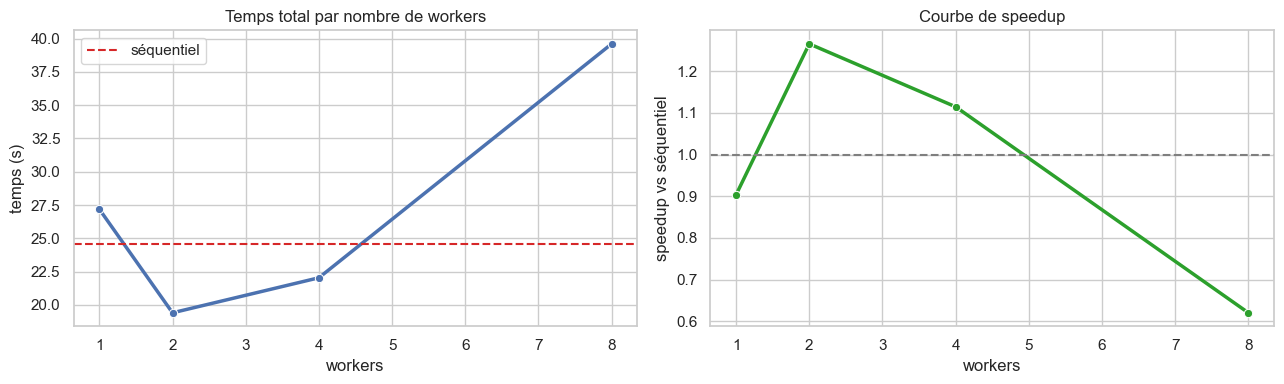

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))



sns.lineplot(data=report, x='workers', y='parallel_s', marker='o', linewidth=2.5, ax=axes[0])

axes[0].axhline(report['sequential_s'].iloc[0], color='tab:red', linestyle='--', label='séquentiel')

axes[0].set_title('Temps total par nombre de workers')

axes[0].set_xlabel('workers')

axes[0].set_ylabel('temps (s)')

axes[0].legend()



sns.lineplot(data=report, x='workers', y='speedup', marker='o', linewidth=2.5, ax=axes[1], color='tab:green')

axes[1].axhline(1.0, color='tab:gray', linestyle='--')

axes[1].set_title('Courbe de speedup')

axes[1].set_xlabel('workers')

axes[1].set_ylabel('speedup vs séquentiel')



plt.tight_layout()

## Export optionnel



Décommente la cellule suivante pour exporter les résultats vers CSV si tu veux les réutiliser dans `RAPPORT.md`.

In [ ]:
# export_path = PROJECT_ROOT / 'data' / 'processed' / 'benchmark_parallel_speedup_report.csv'

# report.to_csv(export_path, index=False)

# print('Exported to', export_path)

## Interprétation attendue



Dans le rapport, commente au minimum:

- la décroissance du temps total quand on augmente `workers`,

- le point à partir duquel les gains ralentissent,

- l'overhead du `ProcessPoolExecutor`, visible notamment pour `workers=1`,

- le rôle du CPU, du disque et du coût de sérialisation inter-processus.